In [2]:
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3


In [3]:
print(platform.system())
print(plt.rcParams['font.family'])

Windows
['sans-serif']


In [4]:
plt.rcParams["font.family"] = "Malgun Gothic"
print(plt.rcParams['font.family'])

['Malgun Gothic']


In [5]:
# 공공데이터 스타일 데이터 생성 (따릉이 일별 대여 기록 — 가상)
np.random.seed(7)
n_days = 180
dates = pd.date_range("2025-01-01", periods=n_days, freq="D")
# 계절성: 봄·여름에 대여 증가
seasonal = 3000 + 2500 * np.sin(np.linspace(0, np.pi, n_days))
rentals = (seasonal + np.random.normal(0, 400, n_days)).round().astype(int)

bike = pd.DataFrame({
    "date": dates,
    "rentals": rentals,
    "avg_temp": (np.linspace(-2, 28, n_days) + np.random.normal(0, 2, n_days)).round(1),
    "rainfall": np.random.choice([0, 0, 0, 0, 5, 12, 30], n_days),
    "station_area": np.random.choice(["강남", "마포", "송파", "종로", " 강남 "], n_days),
})
# 오염 심기: 대여수 결측, 기온 이상치, 중복 행
bike.loc[np.random.choice(n_days, 8, replace=False), "rentals"] = np.nan
bike.loc[50, "avg_temp"] = 250.0     # 센서 오류로 보이는 이상치
bike = pd.concat([bike, bike.iloc[[3]]], ignore_index=True)  # 중복 1건

print("따릉이 데이터 준비 완료:", bike.shape)
bike.head()
bike

따릉이 데이터 준비 완료: (181, 5)


,date,rentals,avg_temp,rainfall,station_area
0,2025-01-01,3676.0,-3.0,12,마포
1,2025-01-02,2857.0,-1.1,0,마포
2,2025-01-03,3101.0,-1.1,0,강남
3,2025-01-04,3295.0,0.9,0,강남
4,2025-01-05,2860.0,-1.1,0,마포
...,...,...,...,...,...
176,2025-06-26,3516.0,22.9,0,강남
177,2025-06-27,3312.0,27.8,0,송파
178,2025-06-28,2514.0,27.4,0,송파
179,2025-06-29,3266.0,26.4,0,강남


In [6]:
# 시나리오 1 — 구조 진단
print("shape:", bike.shape)
bike.info()
print(bike.describe())

shape: (181, 5)
<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          181 non-null    datetime64[us]
 1   rentals       173 non-null    float64       
 2   avg_temp      181 non-null    float64       
 3   rainfall      181 non-null    int64         
 4   station_area  181 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 7.2 KB
                             date      rentals    avg_temp    rainfall
count                         181   173.000000  181.000000  181.000000
mean   2025-03-31 00:31:49.392265  4531.757225   14.169061    5.298343
min           2025-01-01 00:00:00  2514.000000   -4.900000    0.000000
25%           2025-02-14 00:00:00  3841.000000    5.100000    0.000000
50%           2025-03-31 00:00:00  4708.000000   13.100000    0.000000
75%           2025-05-15 00:00:00  524

- 181행, 5열
- date:날짜형 / rentals:실수형 / avg_temp;실수형 / rainfall:정수형 / station_are:문자형 / date열은 제대로 datetime으로 인식됐다.
- avg_temp의 최댓값이 250으로 말이 안되는 숫자가 나왔다 -> 이상치

In [7]:
# 시나리오 2 — 품질 진단
print("[결측치]")
print(bike.isnull().sum())
print("\n중복 행:", bike.duplicated().sum())
print("\n[station_area 값의 종류]")
print(bike["station_area"].unique())
print("\n기온 이상치 확인(상위 3개):")
print(bike["avg_temp"].sort_values(ascending=False).head(3).tolist())

[결측치]
date            0
rentals         8
avg_temp        0
rainfall        0
station_area    0
dtype: int64

중복 행: 1

[station_area 값의 종류]
<StringArray>
['마포', ' 강남 ', '강남', '송파', '종로']
Length: 5, dtype: str

기온 이상치 확인(상위 3개):
[250.0, 31.8, 30.6]


In [8]:
bike[bike['station_area']==' 강남 '].head(5)

,date,rentals,avg_temp,rainfall,station_area
2,2025-01-03,3101.0,-1.1,0,강남
19,2025-01-20,3208.0,1.5,0,강남
27,2025-01-28,3226.0,4.1,0,강남
28,2025-01-29,4599.0,1.8,0,강남
30,2025-01-31,3959.0,0.8,0,강남


[다섯가지 오염유형] 결측치, 이상치, 표기혼재, 날짜포맷혼재, 중복행
- rentals에는 결측치가 존재하고
- avg_temp에서는 이상치가 발견되었다.
- 날짜포맷은 괜찮은 것 같고
- 중복행은 1개 존재한다
- 추가로 station_area에서 ' 강남 '와 같이 표기혼재가 있는지를 확인해보고자 했는데, 있는 걸로 확인되었다.

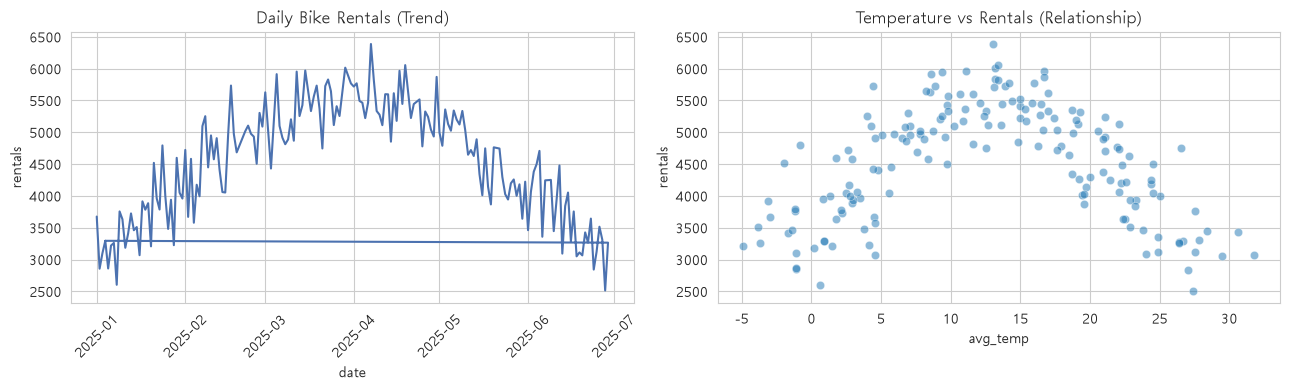

In [9]:
# 시나리오 3 — 시각화 (이상치 제거 후)
clean = bike[(bike["avg_temp"] < 60)].dropna(subset=["rentals"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# 추이
axes[0].plot(clean["date"], clean["rentals"], color="#4C72B0")
axes[0].set_title("Daily Bike Rentals (Trend)")
axes[0].set_xlabel("date"); axes[0].set_ylabel("rentals")
axes[0].tick_params(axis="x", rotation=45)
# 관계
sns.scatterplot(data=clean, x="avg_temp", y="rentals", alpha=0.5, ax=axes[1])
axes[1].set_title("Temperature vs Rentals (Relationship)")
axes[1].set_xlabel("avg_temp"); axes[1].set_ylabel("rentals")
plt.tight_layout(); plt.show()

[추이]
- 봄에서 여름으로 갈 수록 대여량이 늘었지만, 다시 겨울로 갈 수록 대여량이 줄어들었다. -> 계절성이 보인다.

[관계]
- 기온이 높을수록 대여가 많아지지만, 또 기온이 너무 높아지면 대여가 줄어드는 것을 확인할 수 있다.

[심화과제]

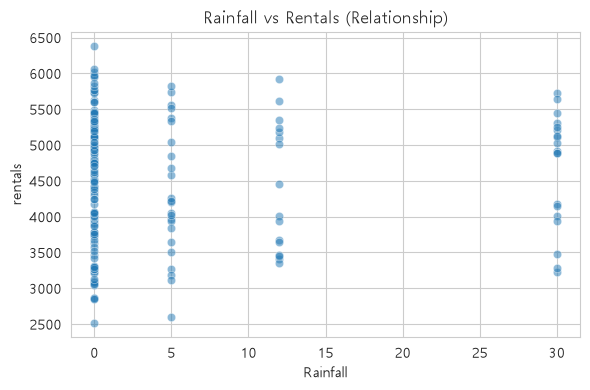

In [10]:
# 강수량과 대여 수의 관계
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=clean, x="rainfall", y="rentals", alpha=0.5, ax=ax)
ax.set_title("Rainfall vs Rentals (Relationship)")
ax.set_xlabel("Rainfall"); ax.set_ylabel("rentals")
plt.tight_layout(); plt.show()

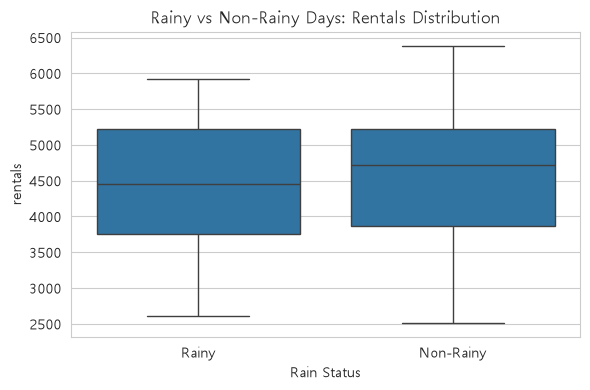

In [12]:
# (추가) 비 온 날 / 안 온 날 대여 수 비교하기
clean["rain_flag"] = clean["rainfall"].apply(lambda x: "Rainy" if x > 0 else "Non-Rainy")

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=clean, x="rain_flag", y="rentals", ax=ax)
ax.set_title("Rainy vs Non-Rainy Days: Rentals Distribution")
ax.set_xlabel("Rain Status")
ax.set_ylabel("rentals")
plt.tight_layout()
plt.show()

[해석]
- 비가 온다고 대여 수가 급격하게 줄어드는 패턴은 보이지 않는다
- 다만 비 오는 날은 대여량이 전체적으로 적기는 하다. 즉, 강수량이 어느 정도는 대여 수를 낮추는 방향으로 작용할 가능성이 있긴 하다. 
- 하지만 그 차이가 워낙 작아보이기 때문에 이 차이가 유의한지는 통계적 검증을 해봐야 알 것 같다. 

[이상치/결측치 처리 솔루션]
- 다음 분석 제안(EDA 5번)에 작성하였습니다. 

# 따릉이 대여 데이터 — 기초 EDA 리포트

## 1. 데이터 개요
- 행/열: (181행, 5열)
- 기간: 2025-01-01 ~ 2025-06-29
- 주요 컬럼: date, rentals, avg_temp, rainfall, station_area

## 2. 구조 진단 (shape / info / describe)
- 자료형 요약: (date:날짜형 / rentals:실수형 / avg_temp;실수형 / rainfall:정수형 / station_are:문자형 / 날짜 열은 datetime으로 인식됨)
- 수치 요약에서 눈에 띈 점: (rentals 평균 4531.76, avg_temp 최댓값 250 → 이상치 의심)

## 3. 품질 진단 (결측 / 중복 / 표기)
- 결측: rentals 8건
- 중복: 1건
- 표기 혼재: station_area에 ' 강남 '(공백) 존재

## 4. 패턴 (시각화에서 읽은 것)
- 추이: (계절성 — 봄~여름 증가 등)
- 관계: (기온과 대여 수의 양의 관계 등 / 그치만 기온이 너무 높아지면 대여가 줄어드는 것을 확인할 수 있다. )

## 5. 다음 분석 제안
- (avg_temp에서 발견된 이상치는 clean dataframe만들면서 처리했는데, 중복행이랑 결측치, 그리고 station_area에서 표기혼재를 처리해야할 것 같다.
중복행은 중복되는 행을 찾은다음에(drop_duplicates()사용) 두 개 중 하나를 삭제하고 테이블을 새로 만들면 될 것 같고, 결측치는 drop.na()를 통해서 해결하고, 표기혼재는 strip()로 처리하면 될 것 같다.(띄어쓰기 문제였기 때문이다.)
그리고 지금은 기온, 대여 수, 계절 말고도 다른 변수를 사용해서 여러가지 분포를 봐야할 것 같다.)